## FESOM grid

In [1]:
import numpy as np
import uxarray as ux

In [2]:
grid_path = "/Users/dlizarbe/Documents/FESOM_data"
data_paths = "/Users/dlizarbe/Documents/FESOM_data/FESOM_uwv.nc"

In [3]:
ds = ux.open_dataset(grid_path,data_paths)
ds

<xarray.UxDataset> Size: 3GB
Dimensions:  (time: 2, nz: 80, n_node: 928133, nz1: 79, n_face: 1841076)
Coordinates:
  * nz       (nz) float64 640B 0.0 2.0 4.1 6.3 ... 5.65e+03 6e+03 6.35e+03
  * time     (time) datetime64[ns] 16B 1998-01-01T23:50:00 1998-01-02T23:50:00
  * nz1      (nz1) float64 632B 1.0 3.05 5.2 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: n_node, n_face
Data variables:
    w        (time, nz, n_node) float32 594MB ...
    v        (time, nz1, n_face) float32 1GB ...
    u        (time, nz1, n_face) float32 1GB ...
    sss      (time, n_node) float32 7MB ...

In [4]:
((ds.v.isel(time=0,nz1=0)**2 + ds.u.isel(time=0,nz1=0)**2)**0.5).plot()

:Image   [x,y]   (x_y var)

In [5]:
print("lon", ds.uxgrid.face_lon.min().data[()], ds.uxgrid.face_lon.max().data[()])
print("lat", ds.uxgrid.face_lat.min().data[()], ds.uxgrid.face_lat.max().data[()])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


lon -179.99968665418334 179.99976723087673
lat -78.49898282580321 89.91004694542535


In [11]:
from parcels import UxGrid

grid = UxGrid(grid=ds.uxgrid, z=ds.coords["nz"], mesh='spherical')#spherical
grid.uxgrid

<uxarray.Grid>
Original Grid Type: FESOM2
Grid Dimensions:
  * n_node: 928133
  * n_edge: 2769313
  * n_face: 1841076
  * n_max_face_nodes: 3
  * two: 2
Grid Coordinates (Spherical):
  * node_lon: (928133,)
  * node_lat: (928133,)
  * face_lon: (1841076,)
  * face_lat: (1841076,)
Grid Coordinates (Cartesian):
  * node_x: (928133,)
  * node_y: (928133,)
  * node_z: (928133,)
  * face_x: (1841076,)
  * face_y: (1841076,)
  * face_z: (1841076,)
Grid Connectivity Variables:
  * edge_face_connectivity: (2769313, 2)
  * edge_node_connectivity: (2769313, 2)
  * face_node_connectivity: (1841076, 3)
Grid Descriptor Variables:
  * n_nodes_per_face: (1841076,)

In [12]:
ds = ds.copy()  # to avoid mutating a shared object
ds.uxgrid.attrs["Conventions"] = "UGRID-1.0"
ds

<xarray.UxDataset> Size: 3GB
Dimensions:  (time: 2, nz: 80, n_node: 928133, nz1: 79, n_face: 1841076)
Coordinates:
  * nz       (nz) float64 640B 0.0 2.0 4.1 6.3 ... 5.65e+03 6e+03 6.35e+03
  * time     (time) datetime64[ns] 16B 1998-01-01T23:50:00 1998-01-02T23:50:00
  * nz1      (nz1) float64 632B 1.0 3.05 5.2 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: n_node, n_face
Data variables:
    w        (time, nz, n_node) float32 594MB ...
    v        (time, nz1, n_face) float32 1GB ...
    u        (time, nz1, n_face) float32 1GB ...
    sss      (time, n_node) float32 7MB ...

In [13]:
import xarray as xr

In [14]:
ds[["u", "v"]]

<xarray.UxDataset> Size: 2GB
Dimensions:  (time: 2, nz1: 79, n_face: 1841076)
Coordinates:
  * time     (time) datetime64[ns] 16B 1998-01-01T23:50:00 1998-01-02T23:50:00
  * nz1      (nz1) float64 632B 1.0 3.05 5.2 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: n_face
Data variables:
    u        (time, nz1, n_face) float32 1GB ...
    v        (time, nz1, n_face) float32 1GB ...

In [18]:
from parcels.interpolators import UXPiecewiseConstantFace
from parcels import Field

U = Field(
    name="u",
    data=ds.u,
    grid=grid,
    # mesh_type="spherical",
    interp_method=UXPiecewiseConstantFace,
)
V = Field(
    name="v",
    data=ds.v,
    grid=grid,
    # mesh_type="spherical",
    interp_method=UXPiecewiseConstantFace,
)
# W = Field(
#     name="w",
#     data=ds.w,
#     grid=grid,
#     # mesh_type="spherical",
#     interp_method=UXPiecewiseConstantFace,
# )

In [20]:
import parcels
U.units = parcels.GeographicPolar()
V.units = parcels.Geographic()

In [21]:
from parcels import VectorField

UV = VectorField(name="UV", U=U, V=V)

In [22]:
from parcels import FieldSet

# fieldset = FieldSet([UV, UV.U, UV.V, W])
fieldset = FieldSet([UV, UV.U, UV.V])

In [25]:
from parcels.kernels import AdvectionEE, AdvectionRK4
from parcels import Particle, ParticleSet

In [40]:
# ## initial position
# lon0 = -50+1
# lon1 = -48+1
# lat0 = 1
# lat1 = -0.5

In [26]:
num_particles = 200
# start_pos_along_line = np.random.uniform(0,1,size=num_particles)
# start_lon = lon0 + start_pos_along_line * (lon1-lon0)
# start_lat = lat0 + start_pos_along_line * (lat1-lat0)

In [29]:
lon_bds = [np.float64(-130), np.float64(-130.5)]
lat_bds = [np.float64(0), np.float64(-0.5)]

In [30]:
lon_bds, lat_bds

([np.float64(-130.0), np.float64(-130.5)], [np.float64(0.0), np.float64(-0.5)])

In [39]:
pset = ParticleSet(
    fieldset,
    lon=np.random.uniform(*lon_bds, size=(num_particles, )),
    lat=np.random.uniform(*lat_bds, size=(num_particles, )),
    # lon = start_lon,
    # lat = start_lat,
    depth=50.0 * np.ones(shape=(num_particles,)),
    # important otherwise initialization appears to take forever?
   # time=ds.time.min().data[()] + np.timedelta64(0, "s") * np.ones(shape=(num_particles,)),
    pclass=Particle,
)
print(len(pset), "particles created")

200 particles created


In [41]:
from tqdm import tqdm
from parcels import ParticleFile
from parcels import FieldOutOfBoundError

# for capturing positions
_lon = [pset.lon.copy()]
_lat = [pset.lat.copy()]

# output / sub-experiment time stepping
# output_dt = np.timedelta64(30, "m")
output_file = ParticleFile(
    store = 'v4try.zarr',
    outputdt = np.timedelta64(30,'m')
    
)

endtime = output_dt


pset.execute(
    runtime=np.timedelta64(3,'h'),
    dt=np.timedelta64(120, "s"),
    pyfunc=AdvectionRK4,
    verbose_progress=True,
    output_file=output_file
)

# # # on to the next sub experiment
# # endtime += output_dt
# # _lon.append(pset.lon.copy())
# # _lat.append(pset.lat.copy())

# # merge captured positions
# lon = np.vstack(_lon)
# lat = np.vstack(_lat)

INFO: Output files are stored in /Users/dlizarbe/Documents/parcels_4_alpha/Parcels_testing_alpha/v4try.zarr
100%|████████████████████████████████████████████████████████████████████████| 10800.0/10800.0 [00:01<00:00, 7436.96it/s]


In [43]:
tracks = xr.open_zarr('v4try.zarr')
tracks

<xarray.Dataset> Size: 26kB
Dimensions:     (trajectory: 200, obs: 6)
Coordinates:
  * obs         (obs) int32 24B 0 1 2 3 4 5
  * trajectory  (trajectory) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199
Data variables:
    lat         (trajectory, obs) float32 5kB dask.array<chunksize=(200, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 5kB dask.array<chunksize=(200, 1), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 10kB dask.array<chunksize=(200, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 5kB dask.array<chunksize=(200, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_grid_mesh:      spherical
    parcels_kernels:        AdvectionRK4
    parcels_version:        0.1.dev7864

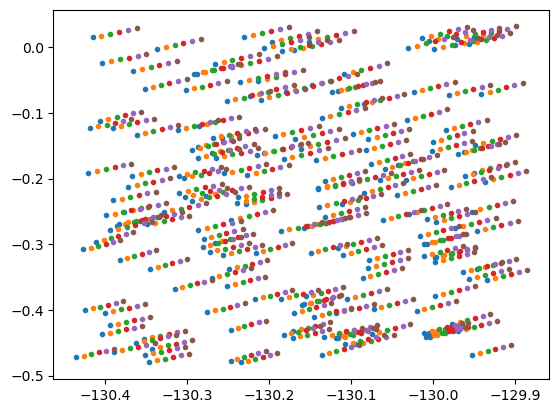

In [45]:
import matplotlib.pyplot as plt
plt.plot(tracks.lon, tracks.lat, ".");


In [46]:
parcels.version

'3.1.5.dev2'